In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install rasterio tqdm -q

In [ ]:
import os
import re
import glob
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt
from tqdm import tqdm

In [ ]:
DRIVE_ROOT = Path('/content/drive/MyDrive/Prj_3_Data')
DATA_ROOT = DRIVE_ROOT / 'ASSAM_PRJ3'

EVENT_FOLDERS = {
    2019: DATA_ROOT / 'S1_ASSAM_2019_STACK',
    2020: DATA_ROOT / 'S1_ASSAM_2020_STACK',
    2021: DATA_ROOT / 'S1_ASSAM_2021_STACK',
    2022: DATA_ROOT / 'S1_ASSAM_2022_STACK',
    2023: DATA_ROOT / 'S1_ASSAM_2023_STACK',
}

In [ ]:
# Your DEM file.
DEM_FILE = DATA_ROOT / 'DEM_ASSAM'

# Processed outputs will be saved back to Drive.
OUTPUT_ROOT = DRIVE_ROOT / 'Assam_Model_Ready'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print('Output folder:', OUTPUT_ROOT)

Output folder: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready


In [ ]:
# ================================================================
# CELL 4: FIND TIFF FILES
# ================================================================
def find_tifs(folder):
    folder = Path(folder)
    return sorted(folder.rglob('*.tif')) + sorted(folder.rglob('*.tiff'))


all_tifs = {}

for year, folder in EVENT_FOLDERS.items():
    files = find_tifs(folder)
    all_tifs[year] = files
    print(year, folder)
    print('  TIFF count:', len(files))
    for f in files[:5]:
        print(' ', f.name)

dem_files = [DEM_FILE] if DEM_FILE.exists() else []
print('\nDEM file exists:', DEM_FILE.exists())
if DEM_FILE.exists():
    print(' ', DEM_FILE)

2019 /content/drive/MyDrive/Prj_3_Data/ASSAM_PRJ3/S1_ASSAM_2019_STACK
  TIFF count: 22
  August_01_to_August_11.tif
  August_05_to_August_15.tif
  August_09_to_August_19.tif
  August_13_to_August_23.tif
  August_17_to_August_27.tif
2020 /content/drive/MyDrive/Prj_3_Data/ASSAM_PRJ3/S1_ASSAM_2020_STACK
  TIFF count: 28
  August_01_to_August_11.tif
  August_05_to_August_15.tif
  August_09_to_August_19.tif
  August_13_to_August_23.tif
  August_17_to_August_27.tif
2021 /content/drive/MyDrive/Prj_3_Data/ASSAM_PRJ3/S1_ASSAM_2021_STACK
  TIFF count: 33
  August_01_to_August_11.tif
  August_05_to_August_15.tif
  August_09_to_August_19.tif
  August_13_to_August_23.tif
  August_17_to_August_27.tif
2022 /content/drive/MyDrive/Prj_3_Data/ASSAM_PRJ3/S1_ASSAM_2022_STACK
  TIFF count: 17
  August_04_to_August_14.tif
  July_03_to_July_13.tif
  July_07_to_July_17.tif
  July_11_to_July_21.tif
  July_15_to_July_25.tif
2023 /content/drive/MyDrive/Prj_3_Data/ASSAM_PRJ3/S1_ASSAM_2023_STACK
  TIFF count: 36
 

In [ ]:
# ================================================================
# CELL 5: INSPECT ONE TIFF
# ================================================================
sample_file = None
for files in all_tifs.values():
    if files:
        sample_file = files[0]
        break

if sample_file is None:
    raise FileNotFoundError('No TIFF files found. Check EVENT_FOLDERS paths.')

with rasterio.open(sample_file) as src:
    sample = src.read()
    profile = src.profile

print('Sample:', sample_file)
print('Shape:', sample.shape)
print('Bands:', profile['count'])
print('CRS:', profile['crs'])
print('Resolution:', src.res)
print('Bounds:', src.bounds)
print('Dtype:', sample.dtype)

Sample: /content/drive/MyDrive/Prj_3_Data/ASSAM_PRJ3/S1_ASSAM_2019_STACK/August_01_to_August_11.tif
Shape: (2, 8556, 14085)
Bands: 2
CRS: EPSG:4326
Resolution: (0.00044915764205976077, 0.00044915764205976077)
Bounds: BoundingBox(left=89.69453533112393, bottom=24.134587580797124, right=96.02092071953567, top=27.977580366260437)
Dtype: float64


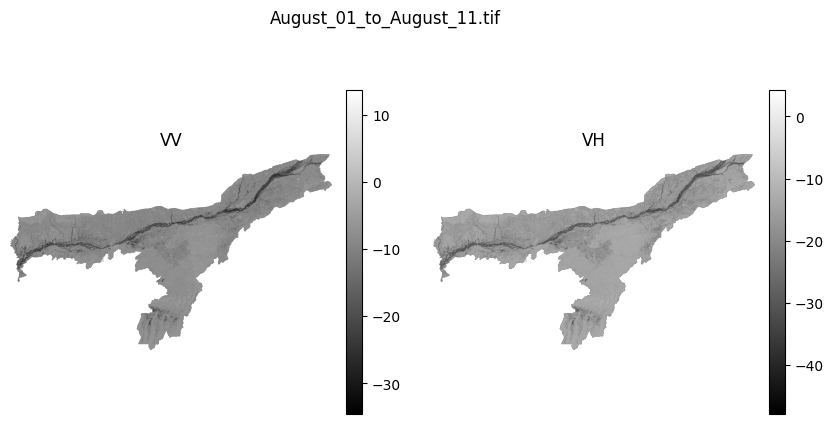

In [ ]:
# ================================================================
# CELL 6: VISUALIZE ONE TIFF (MEMORY SAFE)
# ================================================================
def show_s1_image(path, title=None, stride=10):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)

    # Downsample for visualization
    img = img[:, ::stride, ::stride]

    bands = img.shape[0]
    cols = min(bands, 4)

    plt.figure(figsize=(5 * cols, 5))

    names = ['VV', 'VH', 'VV_minus_VH', 'VV_plus_VH']

    for i in range(cols):
        plt.subplot(1, cols, i + 1)
        plt.imshow(img[i], cmap='gray')
        plt.title(names[i] if i < len(names) else f'Band {i + 1}')
        plt.axis('off')
        plt.colorbar(fraction=0.046, pad=0.04)

    if title:
        plt.suptitle(title)

    plt.show()


show_s1_image(sample_file, sample_file.name, stride=10)

In [ ]:
with rasterio.open(sample_file) as src:
    window = rasterio.windows.Window(0, 0, 512, 512)
    raw = src.read(window=window)

print("RAW VV range:", raw[0].min(), raw[0].max())
print("RAW VH range:", raw[1].min(), raw[1].max())

RAW VV range: nan nan
RAW VH range: nan nan


In [ ]:
# ================================================================
# CELL: FULL SAFE PREPROCESSING (WINDOW + FULL TIF + DEM)
# ================================================================
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.windows import Window
from pathlib import Path

# -------------------------------
# NORMALIZATION
# -------------------------------
def normalize_band(band, min_val, max_val):
    band = np.nan_to_num(band, nan=min_val, posinf=max_val, neginf=min_val)
    band = np.clip(band, min_val, max_val)
    return ((band - min_val) / (max_val - min_val)).astype(np.float32)


# -------------------------------
# DEM HANDLING (FULL ALIGNMENT)
# -------------------------------
def find_dem_tif(dem_path):
    dem_path = Path(dem_path)
    if dem_path.is_file():
        return dem_path

    tifs = list(dem_path.glob('*.tif')) + list(dem_path.glob('*.tiff'))
    if not tifs:
        raise FileNotFoundError(f'No DEM found: {dem_path}')
    return tifs[0]


def preprocess_dem_full(dem_path, target_profile):
    dem_tif = find_dem_tif(dem_path)

    dem_data = np.empty(
        (target_profile['height'], target_profile['width']),
        dtype=np.float32
    )

    with rasterio.open(dem_tif) as src:
        reproject(
            source=rasterio.band(src, 1),
            destination=dem_data,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=target_profile['transform'],
            dst_crs=target_profile['crs'],
            resampling=Resampling.bilinear,
        )

    dem_data = np.nan_to_num(dem_data, nan=0.0)
    dem_data = np.clip(dem_data, 0, 2700) / 2700
    return dem_data.astype(np.float32)


# -------------------------------
# S1 WINDOW PREPROCESSING (SAFE)
# -------------------------------
def preprocess_s1_window(src, window):
    img = src.read(window=window).astype(np.float32)

    if np.isnan(img).all():
        return None

    img = np.nan_to_num(img, nan=-30.0)

    vv = normalize_band(img[0], -30, 5)
    vh = normalize_band(img[1], -35, 0)

    return np.stack([vv, vh, vv - vh, vv + vh], axis=0)


# -------------------------------
# FULL IMAGE PREPROCESSING (FOR ARRAYS)
# -------------------------------
def preprocess_s1_tif(path):
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)
        profile = src.profile.copy()

    if np.isnan(img).all():
        raise ValueError("All-NaN image")

    img = np.nan_to_num(img, nan=-30.0)

    vv = normalize_band(img[0], -30, 5)
    vh = normalize_band(img[1], -35, 0)

    vv_minus_vh = vv - vh
    vv_plus_vh  = vv + vh

    stack = np.stack([vv, vh, vv_minus_vh, vv_plus_vh], axis=0)

    return stack.astype(np.float32), profile


# -------------------------------
# DEBUG: FIND VALID WINDOW
# -------------------------------
def find_valid_window(path, size=512, max_trials=10):
    with rasterio.open(path) as src:
        h, w = src.height, src.width

        for _ in range(max_trials):
            row = np.random.randint(0, h - size)
            col = np.random.randint(0, w - size)

            window = Window(col, row, size, size)
            patch = src.read(window=window)

            if not np.isnan(patch).all():
                print(f"✅ Found valid window at ({row}, {col})")
                return window

    raise RuntimeError("❌ Could not find valid window")


# -------------------------------
# TEST PIPELINE
# -------------------------------
with rasterio.open(sample_file) as src:

    window = find_valid_window(sample_file, size=512)

    x_window = preprocess_s1_window(src, window)
    profile = src.profile.copy()

# Test full image preprocessing
x_full, _ = preprocess_s1_tif(sample_file)

print("Window patch shape:", None if x_window is None else x_window.shape)
print("Window range:", None if x_window is None else (float(x_window.min()), float(x_window.max())))

print("Full image shape:", x_full.shape)
print("Full image range:", float(x_full.min()), float(x_full.max()))

✅ Found valid window at (4778, 524)
Window patch shape: (4, 512, 512)
Window range: (-0.22799012064933777, 2.0)
Full image shape: (4, 8556, 14085)
Full image range: -0.39268577098846436 2.0


In [ ]:
# ================================================================
# CELL: CLASSIFY FILES AS PRE / FLOOD / POST / WINDOW (ASSAM)
# ================================================================
import calendar
import numpy as np
import re

# -------------------------------
# UPDATED EVENT DATES (ASSAM)
# -------------------------------

# EVENT_DATES = {
#     2019: ('2019-06-10', '2019-09-12'),
#     2020: ('2020-05-01', '2020-08-27'),
#     2021: ('2021-05-01', '2021-09-27'),
#     2022: ('2022-06-01', '2022-08-14'),
#     2023: ('2023-05-01', '2023-09-28'),
# }

EVENT_DATES = {
    2019: ('2019-07-20', '2019-08-20'),
    2020: ('2020-07-15', '2020-08-25'),
    2021: ('2021-07-10', '2021-08-20'),
    2022: ('2022-07-05', '2022-08-10'),
    2023: ('2023-07-15', '2023-08-25'),
}

# -------------------------------
# MONTH MAP (case-insensitive)
# -------------------------------
MONTH_TO_NUMBER = {
    month.lower(): idx
    for idx, month in enumerate(calendar.month_name)
    if month
}

# -------------------------------
# PARSE WINDOW DATES
# -------------------------------
def parse_window_dates(path, year):
    match = re.search(
        r'([A-Za-z]+)_(\d{1,2})_to_([A-Za-z]+)_(\d{1,2})',
        path.stem,
    )

    if not match:
        return None, None

    start_month, start_day, end_month, end_day = match.groups()

    start_month_num = MONTH_TO_NUMBER.get(start_month.lower())
    end_month_num = MONTH_TO_NUMBER.get(end_month.lower())

    if start_month_num is None or end_month_num is None:
        return None, None

    start_year = year
    end_year = year

    if end_month_num < start_month_num:
        end_year = year + 1

    start_date = np.datetime64(f'{start_year}-{start_month_num:02d}-{int(start_day):02d}')
    end_date = np.datetime64(f'{end_year}-{end_month_num:02d}-{int(end_day):02d}')

    return start_date, end_date


# -------------------------------
# CLASSIFY FILE
# -------------------------------
def classify_file(path, year=None):
    name = path.name.upper()

    if 'PRE' in name:
        return 'pre'
    if 'FLOOD' in name and 'WINDOW' not in name:
        return 'flood'
    if 'POST' in name:
        return 'post'

    if year is None:
        return 'window'

    start_date, end_date = parse_window_dates(path, year)
    if start_date is None:
        return 'unknown'

    event_start = np.datetime64(EVENT_DATES[year][0])
    event_end = np.datetime64(EVENT_DATES[year][1])

    if end_date <= event_start:
        return 'pre'
    if start_date >= event_end:
        return 'post'
    if start_date < event_end and end_date > event_start:
        return 'flood'

    return 'window'


# -------------------------------
# OVERLAP CALCULATION
# -------------------------------
def window_event_overlap_days(path, year):
    start_date, end_date = parse_window_dates(path, year)
    if start_date is None:
        return 0

    event_start = np.datetime64(EVENT_DATES[year][0])
    event_end = np.datetime64(EVENT_DATES[year][1])

    overlap_start = max(start_date, event_start)
    overlap_end = min(end_date, event_end)

    if overlap_end <= overlap_start:
        return 0

    return int((overlap_end - overlap_start).astype('timedelta64[D]').astype(int))


def days_from_event(path, year, side):
    start_date, end_date = parse_window_dates(path, year)
    if start_date is None:
        return 10**9

    event_start = np.datetime64(EVENT_DATES[year][0])
    event_end = np.datetime64(EVENT_DATES[year][1])

    if side == 'pre':
        return abs(int((event_start - end_date).astype('timedelta64[D]').astype(int)))

    if side == 'post':
        return abs(int((start_date - event_end).astype('timedelta64[D]').astype(int)))

    return 10**9


# -------------------------------
# PICK REPRESENTATIVE FILES
# -------------------------------
def pick_representative_windows(year, groups):
    selected = {'pre': [], 'flood': [], 'post': []}

    if groups['pre']:
        selected['pre'] = [
            min(groups['pre'], key=lambda p: days_from_event(p, year, 'pre'))
        ]

    if groups['flood']:
        selected['flood'] = [
            max(groups['flood'], key=lambda p: window_event_overlap_days(p, year))
        ]

    if groups['post']:
        selected['post'] = [
            min(groups['post'], key=lambda p: days_from_event(p, year, 'post'))
        ]

    return selected


# -------------------------------
# GROUP FILES
# -------------------------------
grouped = {}

for year, files in all_tifs.items():

    grouped[year] = {
        'pre': [],
        'flood': [],
        'post': [],
        'window': [],
        'unknown': []
    }

    for path in files:
        category = classify_file(path, year)
        grouped[year][category].append(path)
# -------------------------------
# PRINT SUMMARY
# -------------------------------
for year, groups in grouped.items():
    print('\nYear:', year)

    for key, files in groups.items():
        print(f'  {key}: {len(files)}')

        for f in files[:3]:
            print('   ', f.name)

    selected = pick_representative_windows(year, groups)

    print('  selected for quick model:')
    for key, files in selected.items():
        print(f'    {key}:', files[0].name if files else 'missing')


Year: 2019
  pre: 8
    July_04_to_July_14.tif
    July_08_to_July_18.tif
    June_10_to_June_20.tif
  flood: 10
    August_01_to_August_11.tif
    August_05_to_August_15.tif
    August_09_to_August_19.tif
  post: 4
    August_21_to_August_31.tif
    August_25_to_September_04.tif
    August_29_to_September_08.tif
  window: 0
  unknown: 0
  selected for quick model:
    pre: July_08_to_July_18.tif
    flood: August_01_to_August_11.tif
    post: August_21_to_August_31.tif

Year: 2020
  pre: 17
    July_04_to_July_14.tif
    June_02_to_June_12.tif
    June_06_to_June_16.tif
  flood: 11
    August_01_to_August_11.tif
    August_05_to_August_15.tif
    August_09_to_August_19.tif
  post: 0
  window: 0
  unknown: 0
  selected for quick model:
    pre: July_04_to_July_14.tif
    flood: August_01_to_August_11.tif
    post: missing

Year: 2021
  pre: 16
    June_02_to_June_12.tif
    June_06_to_June_16.tif
    June_10_to_June_20.tif
  flood: 12
    August_01_to_August_11.tif
    August_05_to_Au

In [ ]:
from pathlib import Path
import numpy as np
import gc  # 👈 important

def save_numpy_array(arr, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    np.save(path, arr)

# ==========================================
# SAVE ARRAYS + DEM (RAM-SAFE VERSION)
# ==========================================
summary_index = []
count = 0

for year, groups in grouped.items():
    print(f"\nProcessing {year}")

    year_out = OUTPUT_ROOT / str(year)
    year_out.mkdir(parents=True, exist_ok=True)

    ref_profile = None

    # ---------------------------
    # SENTINEL ARRAYS
    # ---------------------------
    for stage in ['pre', 'flood', 'post']:
        for tif in groups[stage]:

            try:
                arr, profile = preprocess_s1_tif(tif)

                if ref_profile is None:
                    ref_profile = profile

                out_path = year_out / f"{stage}_{tif.stem}.npy"
                save_numpy_array(arr, out_path)

                summary_index.append({
                    'year': year,
                    'stage': stage,
                    'path': str(out_path),
                    'shape': arr.shape
                })

                count += 1

                # 👇 FREE MEMORY IMMEDIATELY
                del arr
                gc.collect()

            except Exception as e:
                print(f"❌ Skipping {tif.name} → {e}")

    # ---------------------------
    # DEM (ONE PER YEAR)
    # ---------------------------
    if ref_profile is not None:
        try:
            dem = preprocess_dem_full(DEM_FILE, ref_profile)

            dem_path = year_out / "DEM.npy"
            save_numpy_array(dem, dem_path)

            print(f"{year}: DEM saved → {dem.shape}")

            del dem
            gc.collect()

        except Exception as e:
            print(f"❌ DEM failed for {year} → {e}")

    else:
        print(f"{year}: WARNING — no reference profile, DEM skipped")

# ==========================================
# FINAL PRINTS
# ==========================================
print("\n✅ TOTAL SENTINEL ARRAYS SAVED:", count)
print("✅ YEARS PROCESSED:", len(grouped))
print("✅ SUMMARY ENTRIES:", len(summary_index))


Processing 2019
2019: DEM saved → (8556, 14085)

Processing 2020
2020: DEM saved → (8556, 14085)

Processing 2021
2021: DEM saved → (8556, 14085)

Processing 2022
2022: DEM saved → (8556, 14085)

Processing 2023
2023: DEM saved → (8556, 14085)

✅ TOTAL SENTINEL ARRAYS SAVED: 136
✅ YEARS PROCESSED: 5
✅ SUMMARY ENTRIES: 136


In [ ]:
# ================================================================
# CELL 10: SAVE WINDOW ARRAYS
# ================================================================
SAVE_WINDOWS = True

window_index = []

if SAVE_WINDOWS:
    for year, groups in grouped.items():
        year_out = OUTPUT_ROOT / str(year) / 'windows'
        year_out.mkdir(parents=True, exist_ok=True)

        for tif_path in tqdm(groups['window'], desc=f'{year} windows'):
            arr, profile = preprocess_s1_tif(tif_path)
            out_path = year_out / f'{tif_path.stem}.npy'
            save_numpy_array(arr, out_path)

            window_index.append({
                'year': year,
                'source_tif': str(tif_path),
                'array_path': str(out_path),
                'shape': arr.shape,
            })

print('Saved window arrays:', len(window_index))

2019 windows: 0it [00:00, ?it/s]
2020 windows: 0it [00:00, ?it/s]
2021 windows: 0it [00:00, ?it/s]
2022 windows: 0it [00:00, ?it/s]
2023 windows: 0it [00:00, ?it/s]

Saved window arrays: 0


In [ ]:
# ================================================================
# CELL 11: CREATE FAST CHANGE-DETECTION MASKS (FIXED)
# ================================================================
def load_first_stage_array(year, stage):
    files = sorted((OUTPUT_ROOT / str(year)).glob(f'{stage}_*.npy'))

    if not files:
        return None, None

    return np.load(files[0], mmap_mode='r'), files[0]


def make_quick_flood_mask(pre_arr, flood_arr):
    pre_vh = pre_arr[1]
    flood_vh = flood_arr[1]
    pre_vv = pre_arr[0]
    flood_vv = flood_arr[0]

    delta_vh = flood_vh - pre_vh
    delta_vv = flood_vv - pre_vv

    mask = (
        ((delta_vh < -0.05) & (flood_vh < 0.52)) |
        ((delta_vv < -0.05) & (flood_vv < 0.55))
    )

    return mask.astype(np.uint8)


mask_index = []

for year in grouped.keys():   # ✅ use grouped, not EVENT_FOLDERS
    print(f"\nProcessing {year}")

    pre_arr, pre_path = load_first_stage_array(year, 'pre')
    flood_arr, flood_path = load_first_stage_array(year, 'flood')

    if pre_arr is None or flood_arr is None:
        print(f'Skipping {year}: missing PRE or FLOOD array')
        continue

    # ⚠️ mask still large but manageable now
    mask = make_quick_flood_mask(pre_arr, flood_arr)

    out_path = OUTPUT_ROOT / str(year) / f'Assam_{year}_quick_flood_mask.npy'
    np.save(out_path, mask)

    mask_index.append({
        'year': year,
        'pre': str(pre_path),
        'flood': str(flood_path),
        'mask': str(out_path),
        'flood_pixel_fraction': float(mask.mean()),
    })

    print(year, 'mask saved:', out_path, 'flood fraction:', float(mask.mean()))

    # 🔥 FREE MEMORY
    del mask


Processing 2019
2019 mask saved: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready/2019/Assam_2019_quick_flood_mask.npy flood fraction: 0.0354496335031266

Processing 2020
2020 mask saved: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready/2020/Assam_2020_quick_flood_mask.npy flood fraction: 0.027889261136262288

Processing 2021
2021 mask saved: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready/2021/Assam_2021_quick_flood_mask.npy flood fraction: 0.05199143216990678

Processing 2022
2022 mask saved: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready/2022/Assam_2022_quick_flood_mask.npy flood fraction: 0.0540519782134881

Processing 2023
2023 mask saved: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready/2023/Assam_2023_quick_flood_mask.npy flood fraction: 0.051098337201021714


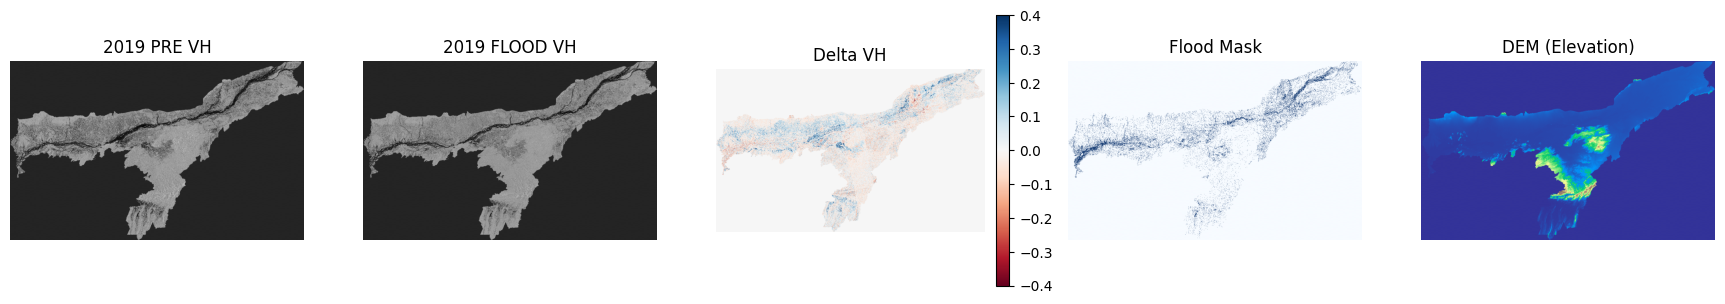

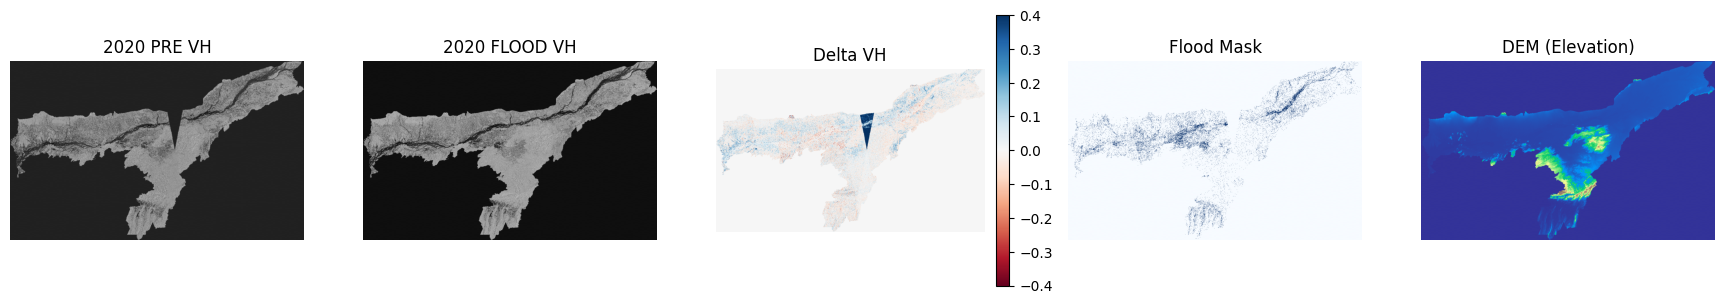

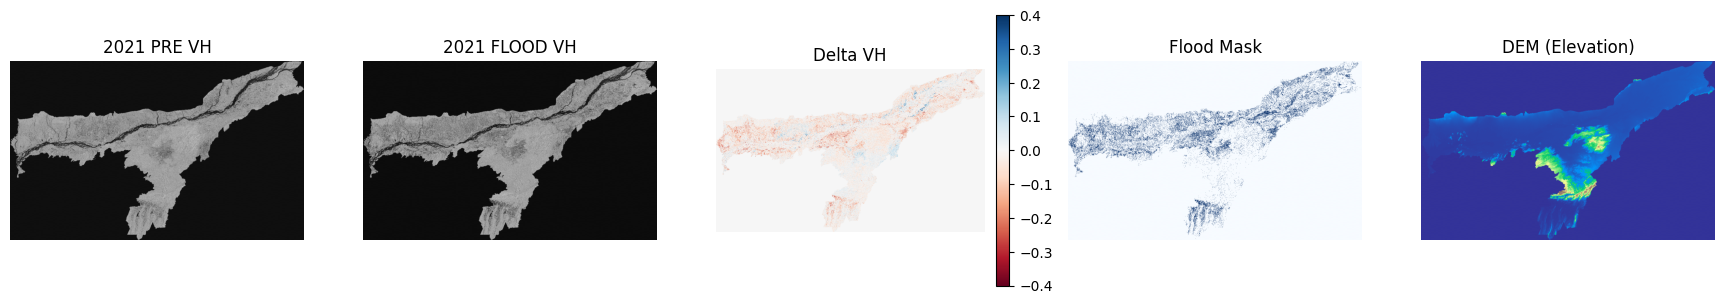

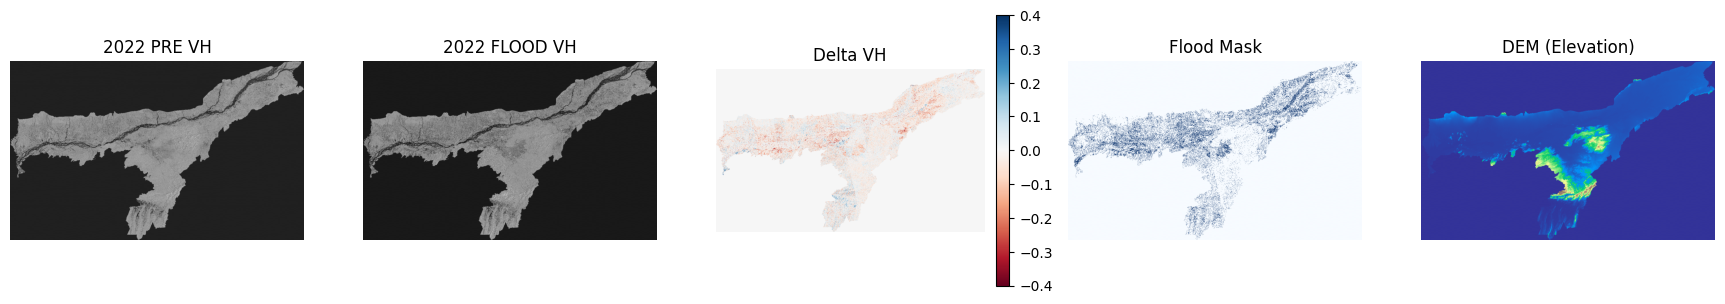

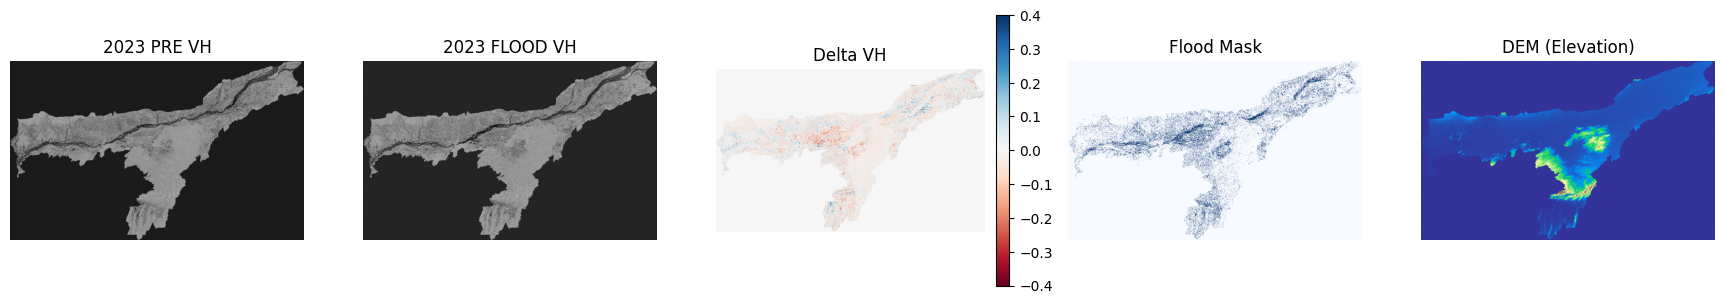

In [ ]:
def visualize_year_change(year, stride=12):
    pre_arr, _ = load_first_stage_array(year, 'pre')
    flood_arr, _ = load_first_stage_array(year, 'flood')
    mask_path = OUTPUT_ROOT / str(year) / f'Assam_{year}_quick_flood_mask.npy'
    dem_path = OUTPUT_ROOT / str(year) / 'DEM.npy'

    if pre_arr is None or flood_arr is None or not mask_path.exists():
        print('Missing data for', year)
        return

    mask = np.load(mask_path)
    delta_vh = flood_arr[1] - pre_arr[1]

    # OPTIONAL DEM
    dem_small = None
    if dem_path.exists():
        dem = np.load(dem_path)
        dem_small = dem[::stride, ::stride]

    pre_vh_small = pre_arr[1, ::stride, ::stride]
    flood_vh_small = flood_arr[1, ::stride, ::stride]
    delta_vh_small = delta_vh[::stride, ::stride]
    mask_small = mask[::stride, ::stride]

    plt.figure(figsize=(22, 5))

    plt.subplot(1, 5 if dem_small is not None else 4, 1)
    plt.imshow(pre_vh_small, cmap='gray')
    plt.title(f'{year} PRE VH')
    plt.axis('off')

    plt.subplot(1, 5 if dem_small is not None else 4, 2)
    plt.imshow(flood_vh_small, cmap='gray')
    plt.title(f'{year} FLOOD VH')
    plt.axis('off')

    plt.subplot(1, 5 if dem_small is not None else 4, 3)
    plt.imshow(delta_vh_small, cmap='RdBu', vmin=-0.4, vmax=0.4)
    plt.title('Delta VH')
    plt.axis('off')
    plt.colorbar(fraction=0.046, pad=0.04)

    plt.subplot(1, 5 if dem_small is not None else 4, 4)
    plt.imshow(mask_small, cmap='Blues')
    plt.title('Flood Mask')
    plt.axis('off')

    if dem_small is not None:
        plt.subplot(1, 5, 5)
        plt.imshow(dem_small, cmap='terrain')
        plt.title('DEM (Elevation)')
        plt.axis('off')

    plt.show()

for year in EVENT_FOLDERS.keys():
    visualize_year_change(year, stride=12)

In [ ]:
# ================================================================
# CELL 13: PATCH EXTRACTION (RAM SAFE VERSION)
# ================================================================
PATCH_SIZE = 128
STRIDE = 128
CHUNK_SIZE = 2000   # 🔥 controls RAM usage

for year in grouped.keys():

    print(f"\nProcessing {year}")

    pre_arr, _ = load_first_stage_array(year, 'pre')
    flood_arr, _ = load_first_stage_array(year, 'flood')

    mask_path = OUTPUT_ROOT / str(year) / f'Assam_{year}_quick_flood_mask.npy'
    dem_path  = OUTPUT_ROOT / str(year) / 'DEM.npy'

    if pre_arr is None or flood_arr is None or not mask_path.exists() or not dem_path.exists():
        print(f"{year}: missing data — skipping")
        continue

    # 🔥 memory-safe loads
    mask = np.load(mask_path, mmap_mode='r')
    dem  = np.load(dem_path, mmap_mode='r')

    _, h, w = pre_arr.shape

    patch_dir = OUTPUT_ROOT / str(year) / 'patches'
    patch_dir.mkdir(parents=True, exist_ok=True)

    X1, X2, XD, Y = [], [], [], []
    chunk_id = 0

    for i in range(0, h - PATCH_SIZE + 1, STRIDE):
        for j in range(0, w - PATCH_SIZE + 1, STRIDE):

            mask_patch = mask[i:i+PATCH_SIZE, j:j+PATCH_SIZE]
            flood_fraction = mask_patch.mean()

            keep_empty = (flood_fraction == 0 and len(Y) % 5 == 0)

            if flood_fraction >= 0.01 or keep_empty:

                X1.append(pre_arr[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE])
                X2.append(flood_arr[:, i:i+PATCH_SIZE, j:j+PATCH_SIZE])
                XD.append(dem[None, i:i+PATCH_SIZE, j:j+PATCH_SIZE])
                Y.append(mask_patch[None])

                # 🔥 SAVE IN CHUNKS
                if len(Y) >= CHUNK_SIZE:
                    np.save(patch_dir / f'X_pre_{chunk_id}.npy',  np.array(X1, dtype=np.float32))
                    np.save(patch_dir / f'X_flood_{chunk_id}.npy', np.array(X2, dtype=np.float32))
                    np.save(patch_dir / f'X_dem_{chunk_id}.npy',   np.array(XD, dtype=np.float32))
                    np.save(patch_dir / f'y_mask_{chunk_id}.npy',  np.array(Y, dtype=np.uint8))

                    print(f"Saved chunk {chunk_id} → {len(Y)} patches")

                    # clear memory
                    X1, X2, XD, Y = [], [], [], []
                    chunk_id += 1

    # save remaining
    if Y:
        np.save(patch_dir / f'X_pre_{chunk_id}.npy',  np.array(X1, dtype=np.float32))
        np.save(patch_dir / f'X_flood_{chunk_id}.npy', np.array(X2, dtype=np.float32))
        np.save(patch_dir / f'X_dem_{chunk_id}.npy',   np.array(XD, dtype=np.float32))
        np.save(patch_dir / f'y_mask_{chunk_id}.npy',  np.array(Y, dtype=np.uint8))

        print(f"Saved final chunk {chunk_id} → {len(Y)} patches")


Processing 2019
Saved chunk 0 → 2000 patches
Saved final chunk 1 → 206 patches

Processing 2020
Saved chunk 0 → 2000 patches
Saved final chunk 1 → 111 patches

Processing 2021
Saved chunk 0 → 2000 patches
Saved final chunk 1 → 166 patches

Processing 2022
Saved chunk 0 → 2000 patches
Saved final chunk 1 → 239 patches

Processing 2023
Saved chunk 0 → 2000 patches
Saved final chunk 1 → 237 patches


In [ ]:
print('Done.')
print('Model-ready outputs saved to:', OUTPUT_ROOT)

for year in EVENT_FOLDERS.keys():
    patch_dir = OUTPUT_ROOT / str(year) / 'patches'
    dem_path = OUTPUT_ROOT / str(year) / 'DEM.npy'

    print('\n', year)

    if patch_dir.exists():
        for f in sorted(patch_dir.glob('*.npy')):
            arr = np.load(f, mmap_mode='r')
            print(' ', f.name, arr.shape, arr.dtype)
    else:
        print(' no patches folder')

    # OPTIONAL: check DEM separately
    if dem_path.exists():
        dem = np.load(dem_path, mmap_mode='r')
        print(' DEM.npy', dem.shape, dem.dtype)

Done.
Model-ready outputs saved to: /content/drive/MyDrive/Prj_3_Data/Assam_Model_Ready

 2019
  X_dem_0.npy (2000, 1, 128, 128) float32
  X_dem_1.npy (206, 1, 128, 128) float32
  X_flood_0.npy (2000, 4, 128, 128) float32
  X_flood_1.npy (206, 4, 128, 128) float32
  X_pre_0.npy (2000, 4, 128, 128) float32
  X_pre_1.npy (206, 4, 128, 128) float32
  y_mask_0.npy (2000, 1, 128, 128) uint8
  y_mask_1.npy (206, 1, 128, 128) uint8
 DEM.npy (8556, 14085) float32

 2020
  X_dem_0.npy (2000, 1, 128, 128) float32
  X_dem_1.npy (111, 1, 128, 128) float32
  X_flood_0.npy (2000, 4, 128, 128) float32
  X_flood_1.npy (111, 4, 128, 128) float32
  X_pre_0.npy (2000, 4, 128, 128) float32
  X_pre_1.npy (111, 4, 128, 128) float32
  y_mask_0.npy (2000, 1, 128, 128) uint8
  y_mask_1.npy (111, 1, 128, 128) uint8
 DEM.npy (8556, 14085) float32

 2021
  X_dem_0.npy (2000, 1, 128, 128) float32
  X_dem_1.npy (166, 1, 128, 128) float32
  X_flood_0.npy (2000, 4, 128, 128) float32
  X_flood_1.npy (166, 4, 128, 128)

# unet training


In [ ]:
# ================================================================
# CELL 2: IMPORTS
# ================================================================
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split


print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: []


In [ ]:
# ================================================================
# CELL 3: PATHS AND SETTINGS
# ================================================================
DRIVE_ROOT = Path('/content/drive/MyDrive/Prj_3_Data')
DATA_ROOT = DRIVE_ROOT / 'Assam_Model_Ready'
MODEL_DIR = DRIVE_ROOT / 'Assam_Models'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

YEARS = [2019, 2020, 2021, 2022, 2023]
PATCH_SIZE = 128

BATCH_SIZE = 8
EPOCHS = 20
LEARNING_RATE = 1e-4